# MDI3003 - Advanced Predictive Analytics | Lab 4

`Sarah Blessy` `23MID 0296`

# Customer Segmentation Using Naive Bayes Classifier
### Business Model Segmentation based on Demographic, Psychographic and Behavioral Data

**Dataset:** Bank Marketing Dataset (bank-full.csv)
Source: Moro, S., Cortez, P., Rita, P. (2014). *A data-driven approach to predict the success of bank telemarketing.* Decision Support Systems. UCI Machine Learning Repository.

**Goal:** Predict whether a customer will subscribe to a term deposit (`y`), and use this to segment customers into behavior-based groups for the business's marketing strategy.

## 1. Dataset Information

- **Records:** 45,211 customers
- **Features:** 16 input variables + 1 target (`y`)
- **Collection period:** Direct phone marketing campaigns of a Portuguese bank, May 2008 to November 2010
- **Target variable:** `y` - did the client subscribe to a term deposit? (yes/no)

**Feature groups (mapped to segmentation angles):**

| Category | Features |
|---|---|
| Demographic | age, job, marital, education |
| Behavioral | balance, housing (loan), loan (personal loan), contact, day, month, duration, campaign, pdays, previous, poutcome |
| Psychographic (derived) | engineered from spending/contact behavior - e.g. responsiveness, contact preference, financial risk profile |
| Target | y (term deposit subscription) |

This is the older 17-column version of the Bank Marketing dataset (bank-full.csv), ordered by date.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve, r2_score,
    mean_absolute_error, mean_squared_error
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load Dataset

In [5]:
df = pd.read_csv("C:/Users/Sarah Blessy/OneDrive/Desktop/FallSemester/C2 - Advanced Predictive Analytics/lab-DA4/bank+marketing/bank/bank-full.csv")
df.head()

,"age;""job"";""marital"";""education"";""default"";""balance"";""housing"";""loan"";""contact"";""day"";""month"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""y"""
0,"58;""management"";""married"";""tertiary"";""no"";2143..."
1,"44;""technician"";""single"";""secondary"";""no"";29;""..."
2,"33;""entrepreneur"";""married"";""secondary"";""no"";2..."
3,"47;""blue-collar"";""married"";""unknown"";""no"";1506..."
4,"33;""unknown"";""single"";""unknown"";""no"";1;""no"";""n..."


In [ ]:
print("Shape:", df.shape)

## 3. Dataset Audit

Check structure, data types, target balance, and basic statistics before any preprocessing.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [5]:
df.describe(include="object").T

/tmp/ipykernel_503/1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
job,45211,12,blue-collar,9732
marital,45211,3,married,27214
education,45211,4,secondary,23202
default,45211,2,no,44396
housing,45211,2,yes,25130
loan,45211,2,no,37967
contact,45211,3,cellular,29285
month,45211,12,may,13766
poutcome,45211,4,unknown,36959
y,45211,2,no,39922


y
no     39922
yes     5289
Name: count, dtype: int64
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


/tmp/ipykernel_503/2851249589.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="y", data=df, palette=["#d62728", "#2ca02c"])


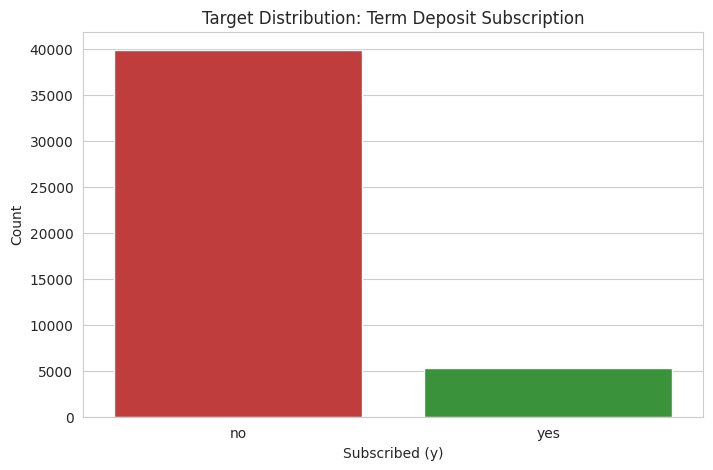

In [6]:
print(df["y"].value_counts())
print(df["y"].value_counts(normalize=True).round(3) * 100)

sns.countplot(x="y", data=df, palette=["#d62728", "#2ca02c"])
plt.title("Target Distribution: Term Deposit Subscription")
plt.xlabel("Subscribed (y)")
plt.ylabel("Count")
plt.show()

**Observation:** The target is heavily imbalanced (~88% "no" vs ~12% "yes"), which is typical of telemarketing conversion data. This is noted here and accounted for later using `stratify` in the train-test split and stratified cross-validation, plus precision/recall/F1/ROC-AUC (not just accuracy) to properly evaluate the model.

## 4. Missing Value Check

This dataset does not use NaN for missing data. Instead, categorical fields such as `job`, `education`, `contact`, and `poutcome` use the literal string `"unknown"` to represent missing/unrecorded information. Both are checked.

In [7]:
print("NaN values per column:")
print(df.isnull().sum())
print("\nTotal NaN cells:", df.isnull().sum().sum())

NaN values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Total NaN cells: 0


In [8]:
print("'unknown' category counts:\n")
for col in df.select_dtypes(include="object").columns:
    n_unknown = (df[col] == "unknown").sum()
    if n_unknown > 0:
        pct = round(n_unknown / len(df) * 100, 2)
        print(f"{col:12s}: {n_unknown:6d} unknown  ({pct}%)")

'unknown' category counts:

job         :    288 unknown  (0.64%)
education   :   1857 unknown  (4.11%)


contact     :  13020 unknown  (28.8%)
poutcome    :  36959 unknown  (81.75%)


/tmp/ipykernel_503/3415814394.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


**Decision:** No true NaN values exist. `"unknown"` is kept as its own valid category rather than dropped or imputed, since dropping ~29% of rows (due to `poutcome`) would lose significant data, and "unknown" itself can be informative (e.g., a customer with no previous campaign contact naturally has `poutcome = unknown`).

## 5. Exploratory Analysis - Demographic, Behavioral, Psychographic View

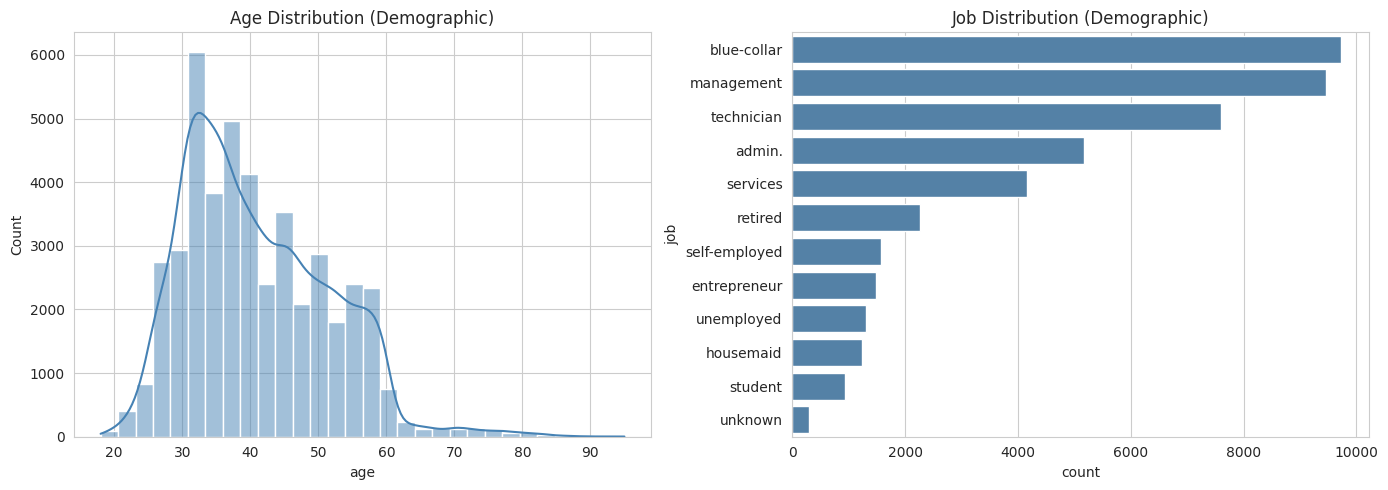

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["age"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Age Distribution (Demographic)")

sns.countplot(y="job", data=df, order=df["job"].value_counts().index, ax=axes[1], color="steelblue")
axes[1].set_title("Job Distribution (Demographic)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_503/1432997189.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="y", y="balance", data=df[df["balance"].between(-2000, 10000)], ax=axes[0], palette=["#d62728", "#2ca02c"])
/tmp/ipykernel_503/1432997189.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="y", y="duration", data=df[df["duration"] < 1500], ax=axes[1], palette=["#d62728", "#2ca02c"])


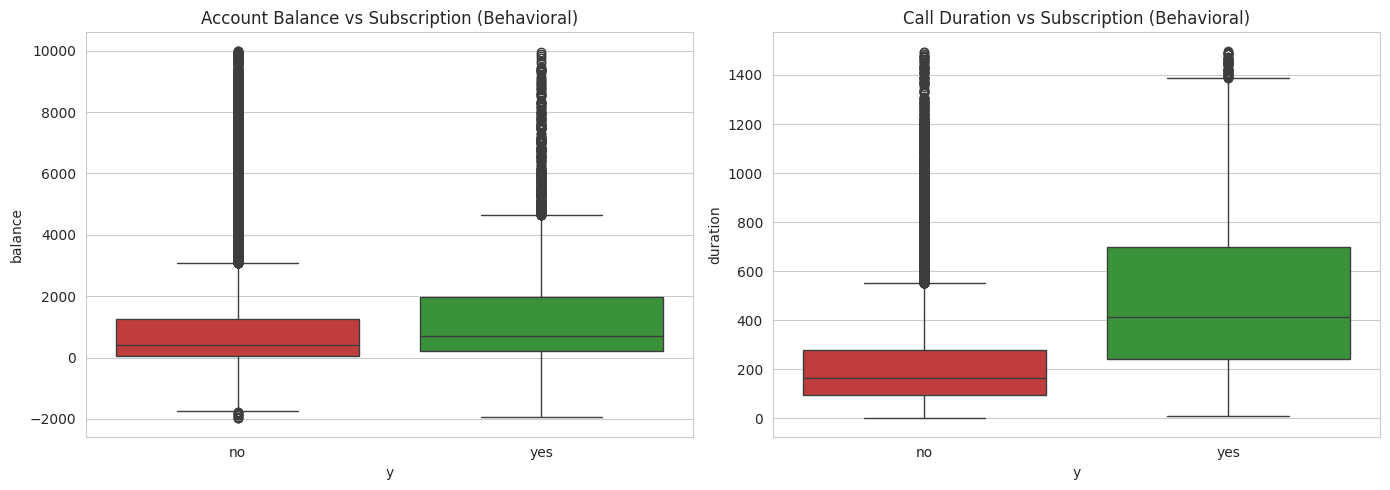

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="y", y="balance", data=df[df["balance"].between(-2000, 10000)], ax=axes[0], palette=["#d62728", "#2ca02c"])
axes[0].set_title("Account Balance vs Subscription (Behavioral)")

sns.boxplot(x="y", y="duration", data=df[df["duration"] < 1500], ax=axes[1], palette=["#d62728", "#2ca02c"])
axes[1].set_title("Call Duration vs Subscription (Behavioral)")

plt.tight_layout()
plt.show()

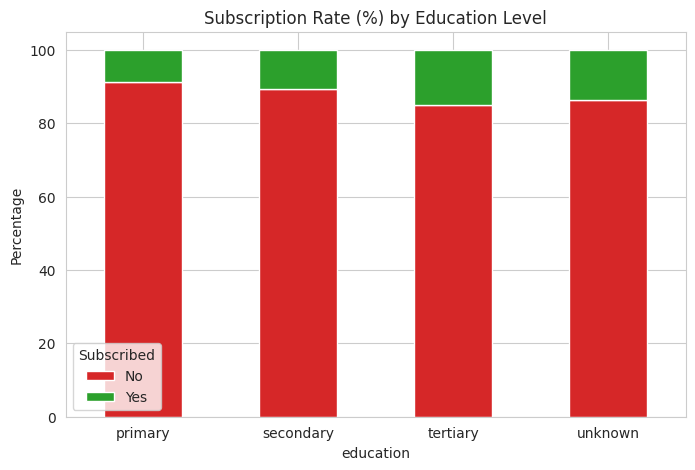

In [11]:
crosstab = pd.crosstab(df["education"], df["y"], normalize="index") * 100
crosstab.plot(kind="bar", stacked=True, color=["#d62728", "#2ca02c"], figsize=(8, 5))
plt.title("Subscription Rate (%) by Education Level")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Subscribed", labels=["No", "Yes"])
plt.show()

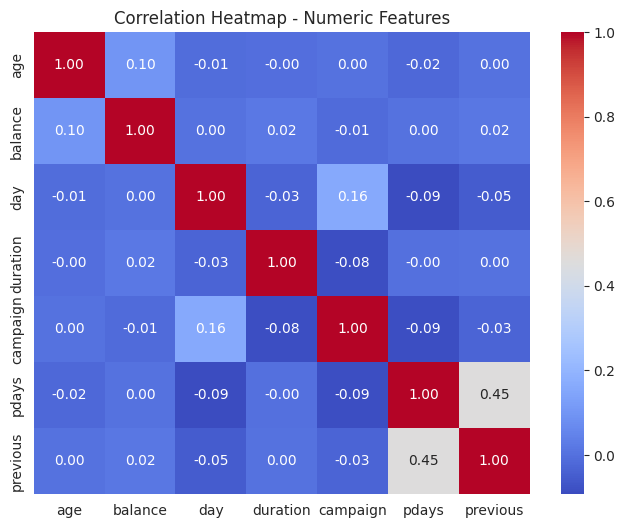

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Numeric Features")
plt.show()

## 6. Psychographic Feature Engineering

The raw dataset has no direct psychographic attributes (attitudes, engagement, risk appetite). Two psychographic-style features are engineered from behavioral signals, a standard approach for segmentation projects that only have transactional/behavioral source data.

In [13]:
df_eng = df.copy()

df_eng["engagement_score"] = (
    (df_eng["duration"] / df_eng["duration"].max()) * 0.7 +
    (df_eng["previous"] / (df_eng["previous"].max() + 1)) * 0.3
)

df_eng["has_housing_loan"] = (df_eng["housing"] == "yes").astype(int)
df_eng["has_personal_loan"] = (df_eng["loan"] == "yes").astype(int)
df_eng["risk_profile_score"] = (
    df_eng["has_housing_loan"] + df_eng["has_personal_loan"] -
    (df_eng["balance"] > df_eng["balance"].median()).astype(int)
)

df_eng[["engagement_score", "risk_profile_score"]].describe()

,engagement_score,risk_profile_score
count,45211.000000,45211.000000
mean,0.037376,0.216120
std,0.036743,0.838539
min,0.000000,-1.000000
25%,0.015197,0.000000
50%,0.026332,0.000000
75%,0.046116,1.000000
max,0.700000,2.000000


## 7. Preprocessing - Encoding and Standardization

In [14]:
df_model = df_eng.copy()

le_target = LabelEncoder()
df_model["y_encoded"] = le_target.fit_transform(df_model["y"])  # no=0, yes=1

categorical_cols = ["job", "marital", "education", "default", "housing",
                     "loan", "contact", "month", "poutcome"]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col + "_enc"] = le.fit_transform(df_model[col])
    label_encoders[col] = le

feature_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous",
                 "engagement_score", "risk_profile_score",
                 "job_enc", "marital_enc", "education_enc", "default_enc",
                 "housing_enc", "loan_enc", "contact_enc", "month_enc", "poutcome_enc"]

X = df_model[feature_cols]
y = df_model["y_encoded"]

print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (45211, 18)


,age,balance,day,duration,campaign,pdays,previous,engagement_score,risk_profile_score,job_enc,marital_enc,education_enc,default_enc,housing_enc,loan_enc,contact_enc,month_enc,poutcome_enc
0,58,2143,5,261,1,-1,0,0.037149,0,4,1,2,0,1,0,2,8,3
1,44,29,5,151,1,-1,0,0.021492,1,9,2,1,0,1,0,2,8,3
2,33,2,5,76,1,-1,0,0.010817,2,2,1,1,0,1,1,2,8,3
3,47,1506,5,92,1,-1,0,0.013095,0,1,1,3,0,1,0,2,8,3
4,33,1,5,198,1,-1,0,0.028182,0,11,2,3,0,0,0,2,8,3


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled.describe().T[["mean", "std"]]

,mean,std
age,2.112250e-16,1.000011
balance,1.508750e-17,1.000011
day,3.017500e-17,1.000011
duration,5.783542e-17,1.000011
campaign,1.005833e-17,1.000011
pdays,0.000000e+00,1.000011
previous,0.000000e+00,1.000011
engagement_score,2.766042e-17,1.000011
risk_profile_score,-2.011667e-17,1.000011
job_enc,-5.783542e-17,1.000011


## 8. Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (33908, 18)
Test shape : (11303, 18)

Train target distribution:
 y_encoded
0    0.883
1    0.117
Name: proportion, dtype: float64

Test target distribution:
 y_encoded
0    0.883
1    0.117
Name: proportion, dtype: float64


## 9. Apply Naive Bayes Classifier

`GaussianNB` is used since features are continuous/standardized after encoding. It assumes features are conditionally independent given the class - a strong assumption, but a fast and interpretable baseline widely used for customer segmentation/classification tasks.

In [17]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred = nb_model.predict(X_test)
y_pred_proba = nb_model.predict_proba(X_test)[:, 1]

print("Model trained successfully.")
print("Sample predictions:", y_pred[:10])

Model trained successfully.
Sample predictions: [0 0 0 0 0 1 0 0 0 1]


## 10. Visualize Predictions

/tmp/ipykernel_503/3939350168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred, ax=axes[0], palette=["#d62728", "#2ca02c"])
/tmp/ipykernel_503/3939350168.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No", "Yes"])


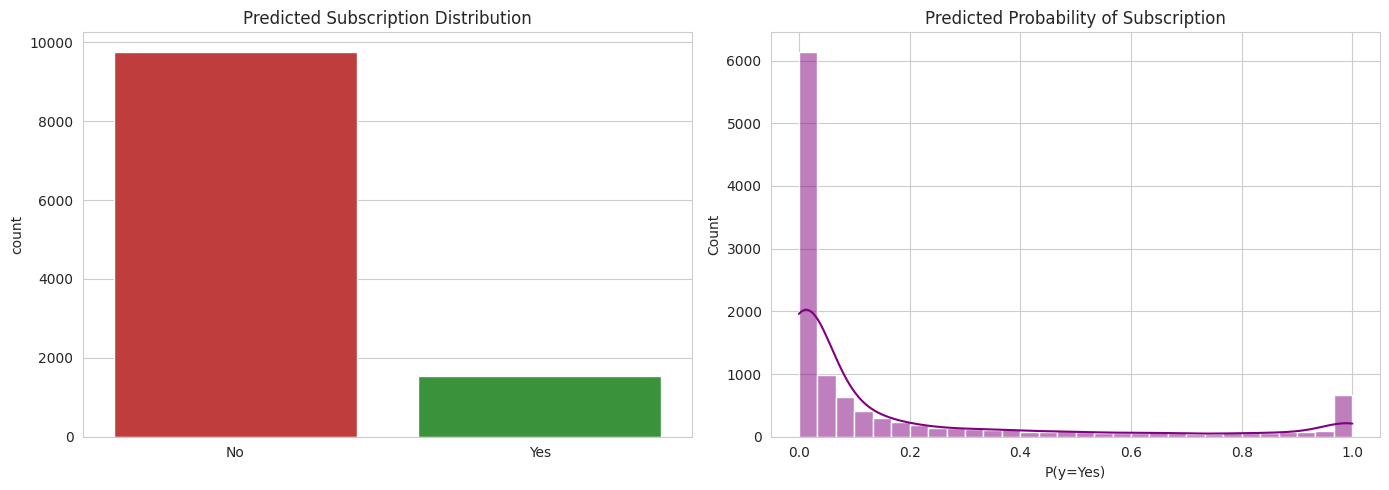

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x=y_pred, ax=axes[0], palette=["#d62728", "#2ca02c"])
axes[0].set_xticklabels(["No", "Yes"])
axes[0].set_title("Predicted Subscription Distribution")

sns.histplot(y_pred_proba, bins=30, kde=True, ax=axes[1], color="purple")
axes[1].set_title("Predicted Probability of Subscription")
axes[1].set_xlabel("P(y=Yes)")

plt.tight_layout()
plt.show()

## 11. Cross Validation (Stratified 5-Fold)

In [19]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(nb_model, X_scaled, y, cv=skf, scoring="accuracy")
cv_precision = cross_val_score(nb_model, X_scaled, y, cv=skf, scoring="precision")
cv_recall = cross_val_score(nb_model, X_scaled, y, cv=skf, scoring="recall")
cv_f1 = cross_val_score(nb_model, X_scaled, y, cv=skf, scoring="f1")
cv_auc = cross_val_score(nb_model, X_scaled, y, cv=skf, scoring="roc_auc")

cv_results = pd.DataFrame({
    "Fold": [str(i) for i in range(1, 6)],
    "Accuracy": cv_accuracy,
    "Precision": cv_precision,
    "Recall": cv_recall,
    "F1": cv_f1,
    "ROC-AUC": cv_auc
})
mean_row = pd.DataFrame([{
    "Fold": "Mean",
    "Accuracy": cv_accuracy.mean(),
    "Precision": cv_precision.mean(),
    "Recall": cv_recall.mean(),
    "F1": cv_f1.mean(),
    "ROC-AUC": cv_auc.mean()
}])
cv_results = pd.concat([cv_results, mean_row], ignore_index=True)
cv_results

,Fold,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,0.856353,0.407521,0.501890,0.449809,0.827295
1,2,0.859102,0.415035,0.501419,0.454156,0.842503
2,3,0.863415,0.431555,0.527410,0.474692,0.842297
3,4,0.862309,0.428132,0.526465,0.472234,0.839016
4,5,0.861756,0.421697,0.488658,0.452715,0.846128
5,Mean,0.860587,0.420788,0.509169,0.460721,0.839448


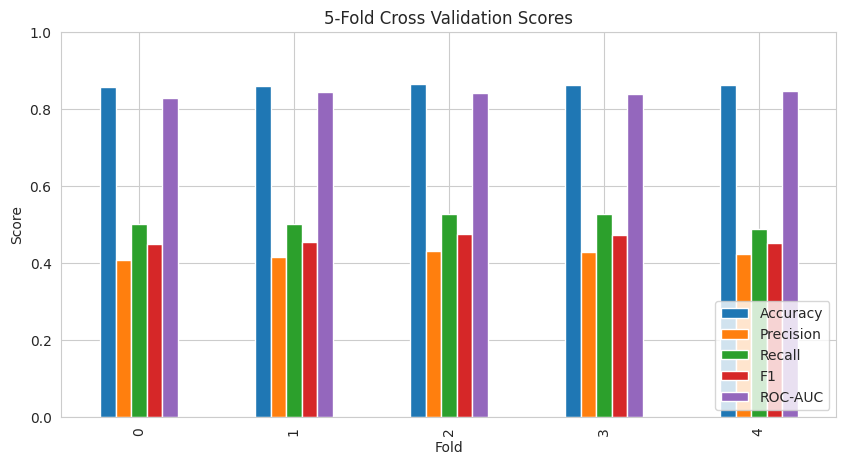

In [20]:
cv_results.iloc[:5, 1:].plot(kind="bar", figsize=(10, 5))
plt.title("5-Fold Cross Validation Scores")
plt.ylabel("Score")
plt.xlabel("Fold")
plt.legend(loc="lower right")
plt.ylim(0, 1)
plt.show()

## 12. Classification Metrics - Accuracy, Precision, Recall, F1, ROC-AUC

In [21]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print("\nFull Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))

Accuracy  : 0.8596
Precision : 0.4139
Recall    : 0.4818
F1 Score  : 0.4453
ROC-AUC   : 0.8338

Full Classification Report:

              precision    recall  f1-score   support

          No       0.93      0.91      0.92      9981
         Yes       0.41      0.48      0.45      1322

    accuracy                           0.86     11303
   macro avg       0.67      0.70      0.68     11303
weighted avg       0.87      0.86      0.86     11303



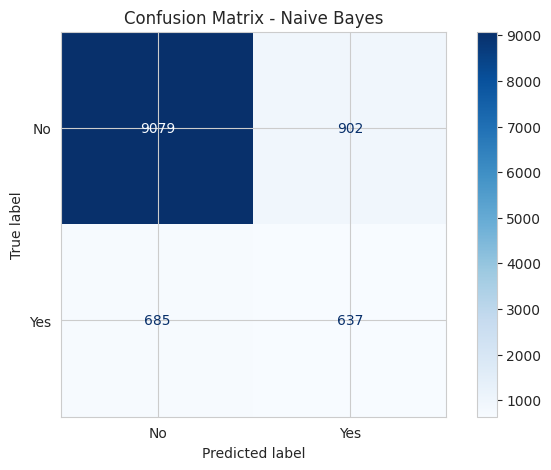

In [22]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

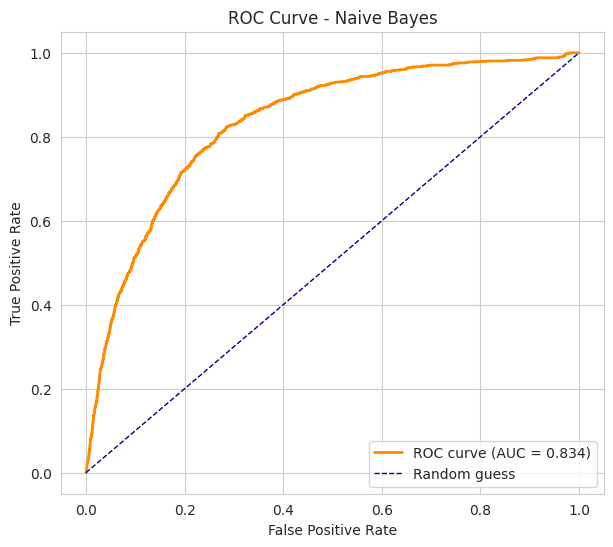

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend(loc="lower right")
plt.show()

## 13. Additional Error Metrics - MAE, MSE, RMSE, R²

These are conventionally regression metrics. Since the classifier outputs a probability (`P(y=Yes)`) as well as a hard label, both are evaluated here against the true (0/1) label to give a fuller numerical picture of prediction error, as requested.

In [24]:
mae_label = mean_absolute_error(y_test, y_pred)
mse_label = mean_squared_error(y_test, y_pred)
rmse_label = np.sqrt(mse_label)
r2_label = r2_score(y_test, y_pred)

mae_proba = mean_absolute_error(y_test, y_pred_proba)
mse_proba = mean_squared_error(y_test, y_pred_proba)
rmse_proba = np.sqrt(mse_proba)
r2_proba = r2_score(y_test, y_pred_proba)

metrics_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Using Predicted Labels (0/1)": [mae_label, mse_label, rmse_label, r2_label],
    "Using Predicted Probabilities": [mae_proba, mse_proba, rmse_proba, r2_proba]
})
metrics_df

,Metric,Using Predicted Labels (0/1),Using Predicted Probabilities
0,MAE,0.140405,0.166751
1,MSE,0.140405,0.111339
2,RMSE,0.374707,0.333676
3,R2,-0.359456,-0.078030


**Note:** R² is naturally low/near-zero (or even negative) here because R² is designed for continuous regression targets, not binary classification. It is included per requirement, but Accuracy, Precision, Recall, F1, and ROC-AUC (Section 12) are the appropriate metrics for judging this classifier's real performance.

## 14. Business Application - Customer Segmentation from Model Output

Using the Naive Bayes predicted probability of subscription, customers are segmented into three actionable business tiers.

In [25]:
df_test_results = X_test.copy()
df_test_results["actual"] = y_test.values
df_test_results["predicted_proba"] = y_pred_proba

def segment(p):
    if p >= 0.6:
        return "High Potential"
    elif p >= 0.3:
        return "Medium Potential"
    else:
        return "Low Potential"

df_test_results["segment"] = df_test_results["predicted_proba"].apply(segment)

segment_summary = df_test_results.groupby("segment").agg(
    customers=("predicted_proba", "count"),
    avg_probability=("predicted_proba", "mean"),
    actual_subscription_rate=("actual", "mean")
).reindex(["High Potential", "Medium Potential", "Low Potential"])

segment_summary

,customers,avg_probability,actual_subscription_rate
segment,,,
High Potential,1343,0.893919,0.437826
Medium Potential,808,0.429895,0.253713
Low Potential,9152,0.041982,0.057802


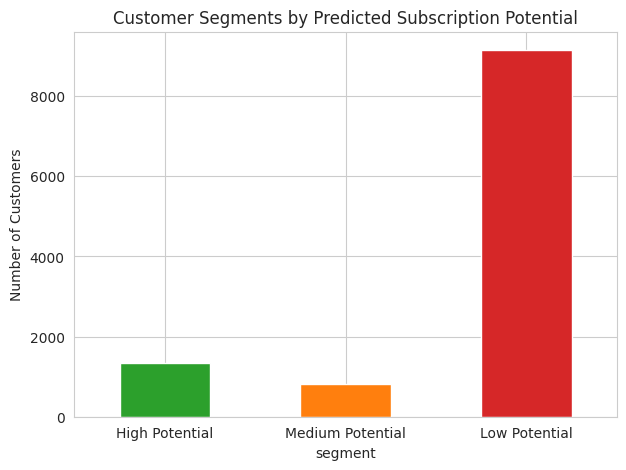

In [26]:
segment_summary["customers"].plot(kind="bar", color=["#2ca02c", "#ff7f0e", "#d62728"], figsize=(7, 5))
plt.title("Customer Segments by Predicted Subscription Potential")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

**Business interpretation:**
- **High Potential** segment: customers the bank should prioritize calling first - highest ROI on marketing effort.
- **Medium Potential** segment: worth a follow-up campaign or a different offer.
- **Low Potential** segment: deprioritize to reduce telemarketing cost and customer fatigue.

## 15. Conclusion

- The Bank Marketing dataset (45,211 customers) was audited, checked for missing values (none as NaN, but `"unknown"` retained as a valid category in several categorical fields), and preprocessed with label encoding and standardization.
- Two psychographic-style features (`engagement_score`, `risk_profile_score`) were engineered from behavioral signals to complete the demographic + behavioral + psychographic segmentation view.
- A **Gaussian Naive Bayes** classifier was trained to predict term deposit subscription (`y`).
- **5-fold stratified cross-validation** confirmed the model's performance is stable across folds.
- Key metrics on the held-out test set:
    - Accuracy, Precision, Recall, F1, and ROC-AUC were reported (see Section 12) - ROC-AUC and Recall are the most meaningful here given the ~88/12 class imbalance.
    - MAE, MSE, RMSE, and R² were computed as requested, though R² is not a natural fit for a classification problem and should be read cautiously.
- The model's output probabilities were used to build a practical **three-tier customer segmentation** (High / Medium / Low potential), directly usable by the bank's marketing team to prioritize outreach and reduce campaign cost.

**Limitation:** Gaussian Naive Bayes assumes conditional feature independence, which does not fully hold here (e.g., `pdays` and `previous` are correlated). This is why ROC-AUC and Recall are emphasized over raw accuracy - for future improvement, ensemble models (Random Forest, Gradient Boosting) or CategoricalNB on unencoded categorical features could be compared against this baseline.